# 02 — Validation: False Positives & Deduplication

**Purpose:** Assess data quality before proceeding to Layer 2 scoring.

**What this notebook does:**
- **4B:** Sample 500 random matches for manual false positive review
- **4C:** Check for and remove duplicate `comment_id` entries
- **Bonus:** Analyze edge cases — short texts, deleted authors, low-score comments

**Decision rule:** If false positive rate > 10%, tighten matching patterns and re-run Step 3.

**Runs on:** Local Python or Google Colab

## Setup

In [1]:
%matplotlib inline

import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive, files
    drive.mount("/content/drive")
    DATA_ROOT = Path("/content/drive/MyDrive/ceo_reddit/data")
    print("Running on Google Colab")
else:
    PROJECT_ROOT = Path.cwd()
    if PROJECT_ROOT.name == "corpus_analysis" or PROJECT_ROOT.name == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent
        if PROJECT_ROOT.name == "notebooks":
            PROJECT_ROOT = PROJECT_ROOT.parent
    DATA_ROOT = PROJECT_ROOT / "data"
    print(f"Running locally — data root: {DATA_ROOT}")

FILTERED_DIR = DATA_ROOT / "filtered"
PROCESSED_DIR = DATA_ROOT / "processed"
REPORTS_DIR = DATA_ROOT / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

assert FILTERED_DIR.exists(), f"Filtered data not found at {FILTERED_DIR}"

Running locally — data root: /home/harkeybour/Desktop/reddit-ceo-characteristics-scrape/data


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 100

## Step 1 — Load Data

In [3]:
parquet_files = sorted(FILTERED_DIR.rglob("*.parquet"))
print(f"Found {len(parquet_files)} parquet files")

dfs = []
for f in parquet_files:
    try:
        dfs.append(pd.read_parquet(f, engine="fastparquet"))
    except Exception as e:
        print(f"  Skipping {f.name}: {e}")

mentions_df = pd.concat(dfs, ignore_index=True)
del dfs

print(f"Total rows: {len(mentions_df):,}")
mentions_df.head(3)

Found 1412 parquet files


Total rows: 696,806


,comment_id,parent_id,subreddit,author,timestamp,year,full_text,post_title,score,is_submission,execid,ceo_matched,company_matched,ticker_matched,match_type,match_variant
0,2t0fy,,business,sophia312,1190657672,2007,Happy Days Are Not Here Again: Legendary Inves...,Happy Days Are Not Here Again: Legendary Inves...,1,True,784,James E. Rogers,DUKE ENERGY CORP,DUK,nickname_last,Jim Rogers
1,2twn6,,business,usmanzali,1190847036,2007,Bill Gates vs. Steve Jobs,Bill Gates vs. Steve Jobs,0,True,14302,Steven P. Jobs,APPLE INC,AAPL,nickname_last,Steve Jobs
2,2vrjk,,business,128bit,1191342895,2007,Jim Rogers Warns of Fallout From Fed Cuts; Say...,Jim Rogers Warns of Fallout From Fed Cuts; Say...,3,True,784,James E. Rogers,DUKE ENERGY CORP,DUK,nickname_last,Jim Rogers


## Step 2 — Deduplication (4C)

A single comment can appear in multiple parquet files if:
- The same `comment_id` was matched by the same CEO pattern across overlapping runs
- Cross-posted content

Note: One comment mentioning **multiple CEOs** is NOT a duplicate — those are separate valid rows with different `execid`.

In [4]:
# Check for true duplicates: same comment_id AND same execid
dup_mask = mentions_df.duplicated(subset=["comment_id", "execid"], keep=False)
dup_count = dup_mask.sum()
unique_dup_comments = mentions_df[dup_mask]["comment_id"].nunique()

print(f"Total rows: {len(mentions_df):,}")
print(f"Duplicate rows (same comment_id + execid): {dup_count:,}")
print(f"Unique comments involved in duplicates: {unique_dup_comments:,}")
print(f"Duplicate rate: {dup_count / len(mentions_df):.2%}")

if dup_count > 0:
    print(f"\nSample duplicates:")
    sample_dup_id = mentions_df[dup_mask]["comment_id"].iloc[0]
    print(mentions_df[mentions_df["comment_id"] == sample_dup_id][
        ["comment_id", "subreddit", "ceo_matched", "match_type", "match_variant", "full_text"]
    ].to_string(index=False))

Total rows: 696,806
Duplicate rows (same comment_id + execid): 336
Unique comments involved in duplicates: 152
Duplicate rate: 0.05%

Sample duplicates:


comment_id subreddit       ceo_matched match_type  match_variant                                                                                   full_text
     6ezyk investing Warren E. Buffett first_last Warren Buffett Yep, you heard it here -- Warren Buffett invests like a girl. And that's a very good thing.
     6ezyk investing Warren E. Buffett first_last Warren Buffett Yep, you heard it here -- Warren Buffett invests like a girl. And that's a very good thing.


In [5]:
# Remove duplicates — keep first occurrence
before = len(mentions_df)
mentions_df = mentions_df.drop_duplicates(subset=["comment_id", "execid"], keep="first")
after = len(mentions_df)
print(f"Removed {before - after:,} duplicates")
print(f"Rows after dedup: {after:,}")

Removed 169 duplicates
Rows after dedup: 696,637


In [6]:
# How many comments mention multiple CEOs? (valid, not duplicates)
multi_ceo = mentions_df.groupby("comment_id")["execid"].nunique()
multi_ceo_comments = (multi_ceo > 1).sum()
print(f"Comments mentioning multiple CEOs: {multi_ceo_comments:,} ({multi_ceo_comments / multi_ceo.shape[0]:.1%})")
print(f"Unique comments: {multi_ceo.shape[0]:,}")
print(f"Total rows (one per CEO match): {len(mentions_df):,}")

if multi_ceo_comments > 0:
    print(f"\nDistribution of CEO mentions per comment:")
    print(multi_ceo.value_counts().sort_index().head(10).to_string())

Comments mentioning multiple CEOs: 48,849 (7.9%)
Unique comments: 620,170
Total rows (one per CEO match): 696,637

Distribution of CEO mentions per comment:
execid
1     571321
2      30143
3      12141
4       5368
5        803
6        180
7         75
8         46
9         28
10        16


## Step 3 — Data Quality Checks

Flag problematic rows before false positive sampling.

In [7]:
# Check for deleted/removed content
deleted_authors = mentions_df["author"].isin(["[deleted]", "[removed]", "AutoModerator"]).sum()
removed_text = mentions_df["full_text"].isin(["[deleted]", "[removed]", ""]).sum()
short_text = (mentions_df["full_text"].str.len() < 20).sum()
very_short = (mentions_df["full_text"].str.len() < 10).sum()

print("=== Data Quality ===")
print(f"Deleted/removed/bot authors: {deleted_authors:,} ({deleted_authors/len(mentions_df):.1%})")
print(f"Deleted/removed/empty text:  {removed_text:,} ({removed_text/len(mentions_df):.1%})")
print(f"Text < 20 chars:             {short_text:,} ({short_text/len(mentions_df):.1%})")
print(f"Text < 10 chars:             {very_short:,} ({very_short/len(mentions_df):.1%})")

print(f"\nSample short texts (<20 chars):")
short_sample = mentions_df[mentions_df["full_text"].str.len() < 20].sample(min(10, short_text), random_state=42)
for _, row in short_sample.iterrows():
    print(f"  [{row['match_type']}] [{row['ceo_matched']}] \"{row['full_text']}\"")

=== Data Quality ===
Deleted/removed/bot authors: 40,540 (5.8%)
Deleted/removed/empty text:  0 (0.0%)
Text < 20 chars:             8,702 (1.2%)
Text < 10 chars:             814 (0.1%)

Sample short texts (<20 chars):
  [first_last] [Elon R. Musk] "Why Elon Musk?"
  [nickname_last] [Steven P. Jobs] "Steve Jobs"
  [nickname_last] [Timothy D. Cook] "Or email Tim Cook."
  [nickname_last] [Alexander C. Karp] "Alex Karp at ADIPEC"
  [full_name] [Jack Dorsey] "Jack Dorsey Quotes"
  [company_ceo] [William Rodney McMullen] "Kroger CEO"
  [first_last] [Elon R. Musk] "Elon Musk"
  [first_last] [Elon R. Musk] "Fuck Elon Musk."
  [first_last] [Elon R. Musk] "Fuck Elon Musk"
  [first_last] [Elon R. Musk] "The Elon musk sub"


In [8]:
# Score distribution — very negative scores may be low-quality
print("=== Reddit Score Distribution ===")
print(mentions_df["score"].describe().to_string())
print(f"\nNegative score comments: {(mentions_df['score'] < 0).sum():,}")
print(f"Zero score comments: {(mentions_df['score'] == 0).sum():,}")
print(f"Score = 1 (default): {(mentions_df['score'] == 1).sum():,}")

=== Reddit Score Distribution ===


count    696637.000000
mean         87.070889
std        1437.188043
min        -505.000000
25%           1.000000
50%           2.000000
75%           6.000000
max      144468.000000

Negative score comments: 40,029
Zero score comments: 44,872
Score = 1 (default): 257,095


## Step 4 — False Positive Sampling (4B)

Sample 500 random matches stratified by match type for manual review.

**What makes a false positive:**
- Name collision: "Tim Cook" is a common name — is this comment about Apple's CEO or someone else?
- "Company CEO" matches a different CEO than the one in our universe
- Text mentions the CEO name but in an irrelevant context (e.g., quoting a different person named "John Smith")
- Deleted/removed content that matched on metadata only

In [9]:
# Stratified sample: proportional to match type distribution
SAMPLE_SIZE = 500

# Exclude deleted/removed text from sampling — those are data quality issues, not false positives
valid_for_review = mentions_df[
    ~mentions_df["full_text"].isin(["[deleted]", "[removed]", ""])
].copy()
print(f"Rows available for review (non-deleted): {len(valid_for_review):,}")

# Stratified sample by match_type
sample = (
    valid_for_review
    .groupby("match_type", group_keys=False)
    .apply(lambda x: x.sample(n=min(len(x), max(10, int(SAMPLE_SIZE * len(x) / len(valid_for_review)))),
                              random_state=42))
    .reset_index(drop=True)
)

# If we got more or less than 500, adjust
if len(sample) > SAMPLE_SIZE:
    sample = sample.sample(n=SAMPLE_SIZE, random_state=42)
elif len(sample) < SAMPLE_SIZE:
    remaining = valid_for_review[~valid_for_review.index.isin(sample.index)]
    extra = remaining.sample(n=min(SAMPLE_SIZE - len(sample), len(remaining)), random_state=42)
    sample = pd.concat([sample, extra])

print(f"Sample size: {len(sample)}")
print(f"\nSample by match type:")
print(sample["match_type"].value_counts().to_string())

Rows available for review (non-deleted): 696,637
Sample size: 500

Sample by match type:
match_type
first_last              274
nickname_last           129
company_ceo              35
full_name                17
ceo_of_company           14
company_ceo_short        12
last_first               10
ceo_of_company_short      9


/tmp/ipykernel_229800/1739164647.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), max(10, int(SAMPLE_SIZE * len(x) / len(valid_for_review)))),


In [10]:
# Prepare review sheet — show the context a human reviewer needs
review_sheet = sample[[
    "comment_id", "subreddit", "year", "ceo_matched", "company_matched",
    "match_type", "match_variant", "full_text", "score", "is_submission"
]].copy()

# Truncate long texts for display (keep full text in export)
review_sheet["text_preview"] = review_sheet["full_text"].str[:300]

# Add review columns
review_sheet["is_false_positive"] = ""  # Reviewer fills: Y/N
review_sheet["fp_reason"] = ""  # Reviewer fills: name_collision / wrong_person / irrelevant / other

# Export to CSV for review
review_path = REPORTS_DIR / "false_positive_audit.csv"
review_sheet.to_csv(review_path, index=False)
print(f"Exported review sheet: {review_path}")
print(f"Columns: {review_sheet.columns.tolist()}")

if IN_COLAB:
    files.download(str(review_path))

Exported review sheet: /home/harkeybour/Desktop/reddit-ceo-characteristics-scrape/data/reports/false_positive_audit.csv
Columns: ['comment_id', 'subreddit', 'year', 'ceo_matched', 'company_matched', 'match_type', 'match_variant', 'full_text', 'score', 'is_submission', 'text_preview', 'is_false_positive', 'fp_reason']


In [11]:
# Preview: show 20 random samples for quick eyeball check
print("=" * 80)
print("QUICK EYEBALL CHECK — 20 random samples")
print("=" * 80)

eyeball = sample.sample(20, random_state=99)
for i, (_, row) in enumerate(eyeball.iterrows(), 1):
    text_preview = row["full_text"][:200].replace("\n", " ")
    print(f"\n--- Sample {i} ---")
    print(f"CEO: {row['ceo_matched']} ({row['company_matched']})")
    print(f"Match: [{row['match_type']}] \"{row['match_variant']}\"")
    print(f"Sub: r/{row['subreddit']} | Year: {row['year']} | Score: {row['score']}")
    print(f"Text: {text_preview}")

QUICK EYEBALL CHECK — 20 random samples

--- Sample 1 ---
CEO: Elon R. Musk (TESLA INC)
Match: [first_last] "Elon Musk"
Sub: r/wallstreetbets | Year: 2022 | Score: -2
Text: Who gives a fuck about elon musk lmfao

--- Sample 2 ---
CEO: Elon R. Musk (TESLA INC)
Match: [first_last] "Elon Musk"
Sub: r/wallstreetbets | Year: 2021 | Score: 2
Text: Make Elon Musk a moderator here!!

--- Sample 3 ---
CEO: Elon R. Musk (TESLA INC)
Match: [first_last] "Elon Musk"
Sub: r/tech | Year: 2015 | Score: 1
Text: Want to work for Elon Musk? New SpaceX headquarters to hire hundreds

--- Sample 4 ---
CEO: Elon R. Musk (TESLA INC)
Match: [first_last] "Elon Musk"
Sub: r/technology | Year: 2022 | Score: 9
Text: Why? Spam bots are a problem with every single website that has ever existed. If it were something you could eliminate, it would have been done already. What makes you think that there is any chance o

--- Sample 5 ---
CEO: Satya Nadella (MICROSOFT CORP)
Match: [ceo_of_company] "CEO of Microsoft"
Sub: 

## Step 5 — Automated False Positive Heuristics

Before manual review, run automated checks to estimate the false positive rate and flag likely issues.

In [12]:
# Heuristic 1: Common name collisions
# Names that are also common English words or very common names
# These have higher false positive risk
common_name_ceos = mentions_df.groupby(["ceo_matched", "company_matched", "match_variant"]).size().reset_index(name="count")
common_name_ceos = common_name_ceos.sort_values("count", ascending=False)

print("=== Top 30 Match Variants by Frequency ===")
print("(Very high-frequency name matches may indicate common name collisions)")
print(common_name_ceos.head(30).to_string(index=False))

=== Top 30 Match Variants by Frequency ===
(Very high-frequency name matches may indicate common name collisions)
           ceo_matched        company_matched   match_variant  count
          Elon R. Musk              TESLA INC       Elon Musk 257881
        Steven P. Jobs              APPLE INC      Steve Jobs  82285
       Timothy D. Cook              APPLE INC        Tim Cook  54287
     Warren E. Buffett     BERKSHIRE HATHAWAY  Warren Buffett  39276
Mark Elliot Zuckerberg     META PLATFORMS INC Mark Zuckerberg  26915
            Lisa T. Su ADVANCED MICRO DEVICES         Lisa Su  22464
           James Dimon    JPMORGAN CHASE & CO     Jamie Dimon   9396
           Jack Dorsey              BLOCK INC     Jack Dorsey   8005
     Alexander C. Karp PALANTIR TECHNOLOG INC       Alex Karp   5322
   Lawrence J. Ellison            ORACLE CORP   Larry Ellison   4711
   Michael Allen Brown        GEN DIGITAL INC   Michael Brown   4363
     Steven A. Ballmer         MICROSOFT CORP   Steve Ball

In [13]:
# Heuristic 2: Check if "Company CEO" matches land in the company's own subreddit
# e.g., "Apple CEO" matched in r/apple — likely true positive
# vs. "Apple CEO" matched in r/worldnews — also likely true, but different signal
company_ceo_matches = mentions_df[mentions_df["match_type"].str.contains("company")].copy()

if len(company_ceo_matches) > 0:
    # Check subreddit vs company alignment
    company_ceo_matches["in_company_sub"] = company_ceo_matches.apply(
        lambda r: r["company_matched"].lower().split()[0] in r["subreddit"].lower(), axis=1
    )
    print(f"'Company CEO' pattern matches: {len(company_ceo_matches):,}")
    print(f"  In company's own subreddit: {company_ceo_matches['in_company_sub'].sum():,}")
    print(f"  In other subreddits: {(~company_ceo_matches['in_company_sub']).sum():,}")
    print(f"\nTop subreddits for 'Company CEO' matches:")
    print(company_ceo_matches["subreddit"].value_counts().head(15).to_string())

'Company CEO' pattern matches: 97,491
  In company's own subreddit: 11,092
  In other subreddits: 86,399

Top subreddits for 'Company CEO' matches:
subreddit
technology         21659
wallstreetbets     18709
news                7698
antiwork            6055
worldnews           5561
apple               5437
economy             2717
AMD_Stock           2220
investing           2184
FluentInFinance     2132
business            1972
teslamotors         1854
Superstonk          1850
StockMarket         1717
stocks              1484


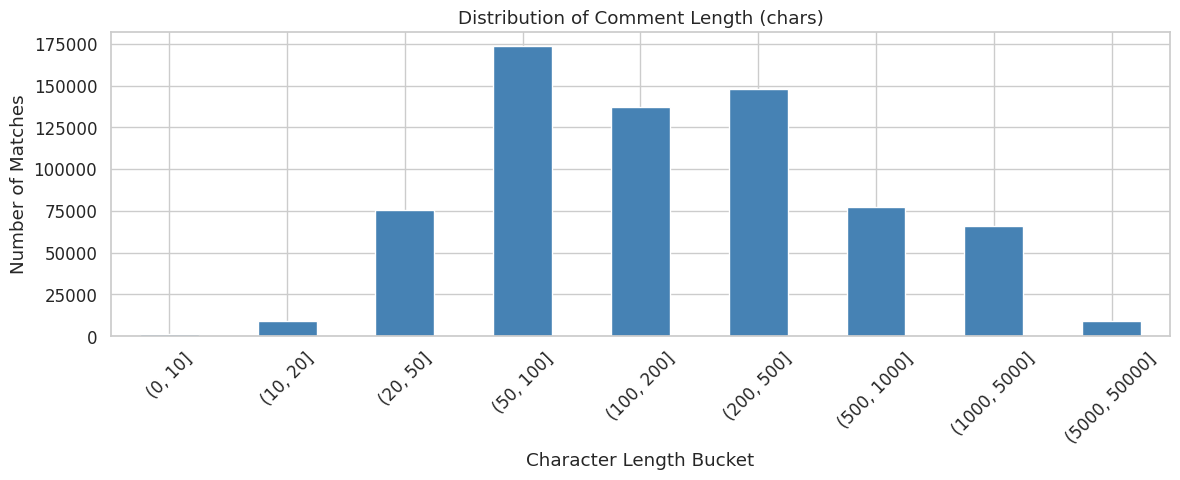

In [14]:
# Heuristic 3: Very short texts — higher FP risk
# A 5-word comment containing "Tim Cook" has less context to confirm relevance
mentions_df["text_len"] = mentions_df["full_text"].str.len()

fig, ax = plt.subplots(figsize=(12, 5))
bins = [0, 10, 20, 50, 100, 200, 500, 1000, 5000, 50000]
mentions_df["text_bucket"] = pd.cut(mentions_df["text_len"], bins=bins)
bucket_counts = mentions_df["text_bucket"].value_counts().sort_index()
bucket_counts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Distribution of Comment Length (chars)")
ax.set_xlabel("Character Length Bucket")
ax.set_ylabel("Number of Matches")
ax.set_xticklabels([str(b) for b in bucket_counts.index], rotation=45)

plt.tight_layout()
plt.savefig(REPORTS_DIR / "text_length_distribution.png", bbox_inches="tight")
plt.show()

## Step 6 — Analyze False Positive Review Results

**Run this after you've manually reviewed `false_positive_audit.csv`.**

Fill in the `is_false_positive` column with `Y` or `N` and optionally the `fp_reason`.

In [15]:
# Load completed review sheet
review_path = REPORTS_DIR / "false_positive_audit.csv"

try:
    reviewed = pd.read_csv(review_path)
    has_reviews = reviewed["is_false_positive"].notna() & (reviewed["is_false_positive"] != "")

    if has_reviews.sum() == 0:
        print("No reviews completed yet.")
        print(f"Open {review_path} and fill in is_false_positive (Y/N) for each row.")
        print("Then re-run this cell.")
    else:
        reviewed_subset = reviewed[has_reviews].copy()
        reviewed_subset["is_fp"] = reviewed_subset["is_false_positive"].str.upper().str.strip() == "Y"

        total_reviewed = len(reviewed_subset)
        fp_count = reviewed_subset["is_fp"].sum()
        fp_rate = fp_count / total_reviewed

        print("=" * 60)
        print("FALSE POSITIVE REVIEW RESULTS")
        print("=" * 60)
        print(f"Reviewed: {total_reviewed}")
        print(f"False positives: {fp_count} ({fp_rate:.1%})")
        print(f"True positives: {total_reviewed - fp_count} ({1 - fp_rate:.1%})")
        print()

        if fp_rate > 0.10:
            print("WARNING: False positive rate > 10%!")
            print("Action: Tighten matching patterns and re-run Step 3.")
        else:
            print("PASS: False positive rate is acceptable.")

        # Breakdown by match type
        print(f"\nFP rate by match type:")
        fp_by_type = reviewed_subset.groupby("match_type")["is_fp"].agg(["sum", "count"])
        fp_by_type["fp_rate"] = (fp_by_type["sum"] / fp_by_type["count"] * 100).round(1)
        fp_by_type.columns = ["false_positives", "total_reviewed", "fp_rate_%"]
        print(fp_by_type.to_string())

        # FP reasons
        if reviewed_subset["fp_reason"].notna().any():
            print(f"\nFP reasons:")
            print(reviewed_subset[reviewed_subset["is_fp"]]["fp_reason"].value_counts().to_string())

        # Which CEOs have the highest FP rates?
        print(f"\nCEOs with most false positives:")
        ceo_fps = reviewed_subset[reviewed_subset["is_fp"]]["ceo_matched"].value_counts().head(10)
        if len(ceo_fps) > 0:
            print(ceo_fps.to_string())
        else:
            print("  (none)")

except FileNotFoundError:
    print(f"Review file not found at {review_path}")
    print("Run Step 4 first to generate the review sheet.")

No reviews completed yet.
Open /home/harkeybour/Desktop/reddit-ceo-characteristics-scrape/data/reports/false_positive_audit.csv and fill in is_false_positive (Y/N) for each row.
Then re-run this cell.


## Step 7 — Summary & Recommendations

In [16]:
print("=" * 60)
print("VALIDATION SUMMARY")
print("=" * 60)
print(f"")
print(f"Total rows after dedup: {len(mentions_df):,}")
print(f"Unique comments: {mentions_df['comment_id'].nunique():,}")
print(f"Unique CEOs mentioned: {mentions_df['execid'].nunique()}")
print(f"")
print(f"Data quality issues:")
print(f"  Deleted/removed text: {removed_text:,}")
print(f"  Very short (<10 chars): {very_short:,}")
print(f"  Deleted/bot authors: {deleted_authors:,}")
print(f"")
print(f"Rows to exclude before Layer 2 scoring:")
exclude = mentions_df[
    mentions_df["full_text"].isin(["[deleted]", "[removed]", ""]) |
    (mentions_df["full_text"].str.len() < 10) |
    mentions_df["author"].isin(["[deleted]", "[removed]"])
]
print(f"  Total excludable: {len(exclude):,} ({len(exclude)/len(mentions_df):.1%})")
print(f"  Clean rows for scoring: {len(mentions_df) - len(exclude):,}")
print(f"")
print(f"Next: Review false_positive_audit.csv, then run Step 6 above.")
print(f"If FP rate < 10%: proceed to Layer 2 scoring.")
print(f"If FP rate > 10%: tighten patterns, re-run Step 3.")

VALIDATION SUMMARY

Total rows after dedup: 696,637


Unique comments: 620,170


Unique CEOs mentioned: 942

Data quality issues:
  Deleted/removed text: 0
  Very short (<10 chars): 814
  Deleted/bot authors: 40,540

Rows to exclude before Layer 2 scoring:


  Total excludable: 41,327 (5.9%)
  Clean rows for scoring: 655,310

Next: Review false_positive_audit.csv, then run Step 6 above.
If FP rate < 10%: proceed to Layer 2 scoring.
If FP rate > 10%: tighten patterns, re-run Step 3.
